In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

In [2]:
data_path = "../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories_monkey.csv"
# data_path = "saved_models/spatial_contrastive/embedded_trajectories.csv"
df = pd.read_csv(data_path)

In [3]:
df.head(5)

,Subject_Id,Session_No,Trial_No,Time,HandPos,TargetPos,time_diff_ms,path,target_poisiton,normalized_trajectory,trajectory_embedding_completion_time,trajectory_embedding_task_type,trajectory_embedding_rmsd,trajectory_embedding_success,trajectory_embedding_within_between_subject,trajectory_embedding_multi_loss
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.006 0.016 0.026 0.036 0.046 0.056 0.066 0.0...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,[-1.8027384 -0.7547033 2.6381545 0.282650...,[-1.2704847 0.3655802 0.4647385 -0.989224...,[-0.11714865 -2.5723224 -1.6749411 -2.474533...,[-1.0218656 -0.17033361 -0.9899339 -0.197075...,[ 1.0672314e+00 -2.7368796e-01 1.5375434e+00 ...,[-1.9680972 -0.8235212 -0.99455655 -0.961210...
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.052 0.062 0.072 0.082 0.092 0.102 0.112 0.1...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,[-1.7841693e+00 -8.2927346e-01 2.6599987e+00 ...,[-1.2285101 0.28994203 0.44881767 -1.013104...,[-0.08287184 -2.4941416 -1.687846 -2.494597...,[-9.8401129e-01 -1.2130158e-01 -9.9083149e-01 ...,[ 1.0931947 -0.35958135 1.5024898 1.229412...,[-1.9687006 -0.7329002 -0.9497438 -1.060264...
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1.064 1.074 1.084 1.094 1.104 1.114 1.124 1.1...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,[-1.7983422 -0.8133227 2.6172345 0.402491...,[-0.84222513 0.03129944 0.3342679 -1.193594...,[ 0.0549759 -2.1119025 -1.8368421 -2.231851...,[-0.72341543 0.08302055 -1.1632334 -0.232339...,[ 0.9995856 -0.66169906 1.4876065 1.263415...,[-2.2671242 -0.723936 -0.61824757 -1.291014...
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.352 0.362 0.372 0.382 0.392 0.402 0.412 0.4...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,[-1.8218230e+00 -6.4916754e-01 2.6334424e+00 ...,[-1.1824117 0.31640446 0.46759894 -1.005319...,[-0.11129288 -2.5438046 -1.764768 -2.380958...,[-1.0115749 -0.11300851 -1.0699037 -0.203063...,[ 1.0806977 -0.29886115 1.5790912 1.279399...,[-2.09113 -0.85278 -0.91633856 -0.985715...
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.046 0.056 0.066 0.076 0.086 0.096 0.106 0.1...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,[-1.82970202e+00 -6.68557048e-01 2.63790560e+...,[-1.2968521 0.3584214 0.5582608 -0.859936...,[-1.4523512e-01 -2.6339672e+00 -1.7881349e+00 ...,[-1.0597457 -0.16324925 -1.0704186 -0.226362...,[ 1.1844195 -0.20105872 1.5504098 1.257361...,[-1.9799824 -0.7871046 -0.9999903 -0.822787...


In [4]:
df.columns = ['participant_id', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_poisiton', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss']
df.columns

Index(['participant_id', 'session_no', 'trial_no', 'Time', 'HandPos',
       'TargetPos', 'time_diff_ms', 'path', 'target_poisiton',
       'normalized_trajectory', 'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss'],
      dtype='object')

In [5]:
def summarize_trajectory_dataset(df):
    """
    Create a comprehensive summary of a trajectory dataset based on participant_id, session_no, and trial_no
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing at minimum the columns: 'participant_id', 'session_no', 'trial_no'
        
    Returns:
    --------
    dict
        Dictionary containing various summary statistics and information
    """
    # Ensure required columns exist
    required_cols = ['participant_id', 'session_no', 'trial_no']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in dataframe")
    
    summary = {}
    
    # Basic counts
    summary['total_participants'] = df['participant_id'].nunique()
    summary['total_sessions'] = df.groupby('participant_id')['session_no'].nunique().sum()
    summary['total_trials'] = len(df)
    
    # Participant statistics
    participants_summary = df.groupby('participant_id').agg(
        sessions_per_participant=('session_no', 'nunique'),
        trials_per_participant=('trial_no', 'count')
    ).describe().T
    
    summary['participants_stats'] = participants_summary
    
    # Session statistics
    session_counts = df.groupby(['participant_id', 'session_no']).size().reset_index(name='trials_per_session')
    summary['session_stats'] = session_counts.describe()
    
    # Distribution of trials per session per participant
    trials_by_session = df.groupby(['participant_id', 'session_no']).size().reset_index(name='trial_count')
    summary['trials_by_session_distribution'] = trials_by_session['trial_count'].describe()
    
    # Check for missing or skipped trials
    trial_numbers = df.groupby(['participant_id', 'session_no'])['trial_no'].apply(list)
    
    missing_trials = {}
    for (pid, session), trials in trial_numbers.items():
        sorted_trials = sorted(trials)
        expected_range = list(range(min(sorted_trials), max(sorted_trials) + 1))
        
        if len(sorted_trials) != len(expected_range):
            missing = set(expected_range) - set(sorted_trials)
            if missing:
                missing_trials[(pid, session)] = list(missing)
    
    summary['missing_trials'] = missing_trials
    summary['has_missing_trials'] = len(missing_trials) > 0
    
    # Check for duplicate trials
    duplicate_trials = df.groupby(['participant_id', 'session_no', 'trial_no']).size()
    duplicate_trials = duplicate_trials[duplicate_trials > 1]
    summary['duplicate_trials'] = duplicate_trials.to_dict() if not duplicate_trials.empty else {}
    summary['has_duplicate_trials'] = not duplicate_trials.empty
    
    return summary

summary = summarize_trajectory_dataset(df)
# # Print summary
print("Trajectory Dataset Summary:")
print(f"Total participants: {summary['total_participants']}")
print(f"Total sessions: {summary['total_sessions']}")
print(f"Total trials: {summary['total_trials']}")

print("\nParticipant statistics:")
print(summary['participants_stats'])

print("\nSession statistics:")
print(summary['session_stats'])

print("\nMissing trials detected:", summary['has_missing_trials'])
print("\nDuplicate trials detected:", summary['has_duplicate_trials'])

Trajectory Dataset Summary:
Total participants: 5
Total sessions: 587
Total trials: 23639

Participant statistics:
                          count    mean          std     min     25%     50%  \
sessions_per_participant    5.0   117.4   102.045578    26.0    29.0    88.0   
trials_per_participant      5.0  4727.8  4662.405838  1160.0  1358.0  1648.0   

                             75%      max  
sessions_per_participant   185.0    259.0  
trials_per_participant    8470.0  11003.0  

Session statistics:
       session_no  trials_per_session
count  587.000000          587.000000
mean    94.679727           40.270869
std     70.787619           12.086007
min      1.000000            4.000000
25%     31.000000           32.000000
50%     80.000000           48.000000
75%    149.000000           48.000000
max    259.000000           50.000000

Missing trials detected: False

Duplicate trials detected: False


In [6]:
# df['participant_id'], unique_participants = pd.factorize(df['participant_id'])
df['task_type'] = df.apply(lambda x: 0, axis=1)
df

,participant_id,session_no,trial_no,Time,HandPos,TargetPos,time_diff_ms,path,target_poisiton,normalized_trajectory,trajectory_embedding_completion_time,trajectory_embedding_task_type,trajectory_embedding_rmsd,trajectory_embedding_success,trajectory_embedding_within_between_subject,trajectory_embedding_multi_loss,task_type
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.006 0.016 0.026 0.036 0.046 0.056 0.066 0.0...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,[-1.8027384 -0.7547033 2.6381545 0.282650...,[-1.2704847 0.3655802 0.4647385 -0.989224...,[-0.11714865 -2.5723224 -1.6749411 -2.474533...,[-1.0218656 -0.17033361 -0.9899339 -0.197075...,[ 1.0672314e+00 -2.7368796e-01 1.5375434e+00 ...,[-1.9680972 -0.8235212 -0.99455655 -0.961210...,0
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.052 0.062 0.072 0.082 0.092 0.102 0.112 0.1...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,[-1.7841693e+00 -8.2927346e-01 2.6599987e+00 ...,[-1.2285101 0.28994203 0.44881767 -1.013104...,[-0.08287184 -2.4941416 -1.687846 -2.494597...,[-9.8401129e-01 -1.2130158e-01 -9.9083149e-01 ...,[ 1.0931947 -0.35958135 1.5024898 1.229412...,[-1.9687006 -0.7329002 -0.9497438 -1.060264...,0
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1.064 1.074 1.084 1.094 1.104 1.114 1.124 1.1...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,[-1.7983422 -0.8133227 2.6172345 0.402491...,[-0.84222513 0.03129944 0.3342679 -1.193594...,[ 0.0549759 -2.1119025 -1.8368421 -2.231851...,[-0.72341543 0.08302055 -1.1632334 -0.232339...,[ 0.9995856 -0.66169906 1.4876065 1.263415...,[-2.2671242 -0.723936 -0.61824757 -1.291014...,0
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.352 0.362 0.372 0.382 0.392 0.402 0.412 0.4...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,[-1.8218230e+00 -6.4916754e-01 2.6334424e+00 ...,[-1.1824117 0.31640446 0.46759894 -1.005319...,[-0.11129288 -2.5438046 -1.764768 -2.380958...,[-1.0115749 -0.11300851 -1.0699037 -0.203063...,[ 1.0806977 -0.29886115 1.5790912 1.279399...,[-2.09113 -0.85278 -0.91633856 -0.985715...,0
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.046 0.056 0.066 0.076 0.086 0.096 0.106 0.1...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,[-1.82970202e+00 -6.68557048e-01 2.63790560e+...,[-1.2968521 0.3584214 0.5582608 -0.859936...,[-1.4523512e-01 -2.6339672e+00 -1.7881349e+00 ...,[-1.0597457 -0.16324925 -1.0704186 -0.226362...,[ 1.1844195 -0.20105872 1.5504098 1.257361...,[-1.9799824 -0.7871046 -0.9999903 -0.822787...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23634,Scott_2001_e5,88,16,[0.681;0.691;0.701;0.711;0.721;0.731;0.741;0.7...,[-5.489 295.829;-5.39344 295.876;-5.1416 295.8...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[0.681 0.691 0.701 0.711 0.721 0.731 0.741 0.7...,"[(-5.489, 295.829), (-5.39344, 295.876), (-5.1...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 6.81000000e...,[-1.81011903e+00 -7.06741929e-01 2.63281202e+...,[-1.0391006 0.21313971 0.39141977 -1.113281...,[-0.05647622 -2.366653 -1.7931738 -2.288031...,[-9.2182469e-0

In [ ]:
## E-E Ratio Calculation

In [7]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

def calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi',
                                             distance_metric='euclidean', window_size=6):
    """
    Calculate exploration and exploitation scores for sequential trials.
    Uses a rolling window approach to determine how much a participant is exploring vs exploiting.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing trajectory data with columns:
        - participant_id: to group trials by participant
        - task_type: to separate unimanual (0) and bimanual (1) tasks
        - day, block, trial_no: to order trials chronologically
        - embedding_column: trajectory embeddings
    
    embedding_column : str, default='trajectory_embedding_weighted_multi'
        Column name for the trajectory embeddings to use
    
    distance_metric : str, default='euclidean'
        Distance metric to use for measuring embedding similarities
    
    window_size : int, default=5
        Size of the rolling window to use for calculations
        
    Returns:
    --------
    pandas.DataFrame
        Original dataframe with additional columns:
        - exploration_score: higher values indicate more exploration
        - exploitation_score: higher values indicate more exploitation
    """
    
    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()
    
    # Initialize new columns for scores
    result_df['exploration_score'] = np.nan
    result_df['exploitation_score'] = np.nan
    result_df['novelty'] = np.nan
    result_df['avg_similarity_to_window'] = np.nan
    result_df['max_similarity_to_window'] = np.nan
    result_df['trial_seq'] = np.nan
    
    # Ensure embedding column is in numpy array format
    if isinstance(result_df[embedding_column].iloc[0], str):
        # Parse string embeddings properly
        result_df[embedding_column] = result_df[embedding_column].apply(
            lambda x: np.array([float(val) for val in x.strip('[]').split()]) if isinstance(x, str) else x
        )
    
    # Group by participant and task_type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically for this participant and task
        group_df = group_df.sort_values(by=['session_no', 'trial_no'])
        # group_df = group_df.reset_index(drop=True)
        
        # Create a sequence number for trials
        group_df['trial_seq'] = range(1, len(group_df) + 1)
        
        # Store sequence number in the result dataframe
        result_df.loc[group_df.index, 'trial_seq'] = group_df['trial_seq'].values
        
        # Handle missing embeddings by creating placeholder embeddings
        valid_embedding_indices = []
        valid_embeddings = []
        embedding_dim = None
        
        # First pass to identify valid embeddings and determine dimension
        for i, idx in enumerate(group_df.index):
            embedding = group_df.loc[idx, embedding_column]
            if embedding is not None and not (isinstance(embedding, float) and np.isnan(embedding)):
                if embedding_dim is None and hasattr(embedding, 'shape'):
                    embedding_dim = embedding.shape[0]
                valid_embedding_indices.append(i)
                valid_embeddings.append(embedding)
        
        # If we have no valid embeddings or couldn't determine dimension, skip this group
        if not valid_embeddings or embedding_dim is None:
            print(f"Warning: No valid embeddings for participant {participant_id}, task {task_type}")
            continue
        
        # Second pass to process distances only for valid embeddings
        if valid_embeddings:
            # Create array of valid embeddings
            valid_embeddings_array = np.vstack(valid_embeddings)
            
            # Calculate distances between valid embeddings
            valid_distances = cdist(valid_embeddings_array, valid_embeddings_array, metric=distance_metric)
            
            # Create a full distance matrix with NaNs for missing embeddings
            n_trials = len(group_df)
            all_distances = np.full((n_trials, n_trials), np.nan)
            
            # Fill in distances for valid embeddings
            for i, valid_i in enumerate(valid_embedding_indices):
                for j, valid_j in enumerate(valid_embedding_indices):
                    all_distances[valid_i, valid_j] = valid_distances[i, j]
            
            # Calculate scores for each trial in sequence
            for i, idx in enumerate(group_df.index):
                # For the first trial, set default values
                if i == 0:
                    result_df.loc[idx, 'exploration_score'] = 1.0
                    result_df.loc[idx, 'exploitation_score'] = 0.0
                    result_df.loc[idx, 'novelty'] = 1.0
                    result_df.loc[idx, 'avg_similarity_to_window'] = 0.0
                    result_df.loc[idx, 'max_similarity_to_window'] = 0.0
                    continue
                
                # Skip calculation if current trial has missing embedding
                if i not in valid_embedding_indices:
                    # Assign the mean or a default value for missing embeddings
                    if i > 0:
                        # Use the mean of previous valid scores as a fallback
                        valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                        valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                        
                        if len(valid_exploration_scores) > 0:
                            result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                        else:
                            result_df.loc[idx, 'exploration_score'] = 0.5  # Default
                            
                        if len(valid_exploitation_scores) > 0:
                            result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                        else:
                            result_df.loc[idx, 'exploitation_score'] = 0.5  # Default
                    
                    # Set other metrics to NaN or default values
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    continue
                
                # Filter out NaN values from distances to previous trials
                distances_to_previous = all_distances[i, :i]
                valid_previous_distances = distances_to_previous[~np.isnan(distances_to_previous)]
                
                if len(valid_previous_distances) > 0:
                    # Novelty: minimum distance to any previous trial
                    # Higher value means more different (more novel)
                    novelty = np.min(valid_previous_distances)
                    result_df.loc[idx, 'novelty'] = novelty
                    
                    # For window calculations, get start index
                    window_start = max(0, i - window_size)
                    
                    # Calculate distances to the window of previous trials
                    distances_to_window = all_distances[i, window_start:i]
                    valid_window_distances = distances_to_window[~np.isnan(distances_to_window)]
                    
                    if len(valid_window_distances) > 0:
                        # Convert distances to similarities (higher = more similar)
                        similarities_to_window = 1 / (1 + valid_window_distances)
                        
                        # Average similarity to window (measure of exploitation)
                        avg_similarity = np.mean(similarities_to_window)
                        result_df.loc[idx, 'avg_similarity_to_window'] = avg_similarity
                        
                        # Maximum similarity to any trial in window (measure of exploitation)
                        max_similarity = np.max(similarities_to_window)
                        result_df.loc[idx, 'max_similarity_to_window'] = max_similarity
                        
                        # Alternative exploration score: based on novelty (difference from previous trials)
                        # Normalize to keep early trials' scores high
                        trial_position_factor = np.exp(-0.01 * i)  # Decreases slowly with trial number
                        exploration_score = novelty * (0.7 + 0.3 * trial_position_factor)
                        
                        # Alternative exploitation score: based on similarity to window
                        # We use max similarity as the primary factor
                        exploitation_score = max_similarity
                        # print(participant_id, idx, exploration_score, exploitation_score)
                        result_df.loc[idx, 'exploration_score'] = exploration_score
                        result_df.loc[idx, 'exploitation_score'] = exploitation_score
                    else:
                        # No valid window distances
                        result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                        result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                        
                        # Use default values or interpolate from other trials
                        if i > 1:
                            # Use mean of previous scores
                            valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                            valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                            
                            if len(valid_exploration_scores) > 0:
                                result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                            else:
                                result_df.loc[idx, 'exploration_score'] = 0.5
                                
                            if len(valid_exploitation_scores) > 0:
                                result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                            else:
                                result_df.loc[idx, 'exploitation_score'] = 0.5
                else:
                    # No valid previous distances, set defaults
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'exploration_score'] = 0.5  # Default mid-point
                    result_df.loc[idx, 'exploitation_score'] = 0.5  # Default mid-point
    
    # Normalize scores to [0,1] range
    for score_col in ['exploration_score', 'exploitation_score']:
        min_val = result_df[score_col].min()
        max_val = result_df[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            result_df[score_col] = (result_df[score_col] - min_val) / (max_val - min_val)
    
    # Add task labels
    result_df['task_label'] = result_df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    return result_df

def calculate_exploration_exploitation_ratio(df, smoothing=0.01):
    """
    Calculate exploration/exploitation ratio for each trial.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration_score and exploitation_score columns
    
    smoothing : float, default=0.01
        Small value to avoid division by zero
    
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional column:
        - exploration_exploitation_ratio: ratio of exploration to exploitation
    """
    result_df = df.copy()
    
    # Calculate ratio (with smoothing to avoid division by zero)
    result_df['exploration_exploitation_ratio'] = (
        result_df['exploration_score'] / (result_df['exploitation_score'] + smoothing)
    )
    
    return result_df

def calculate_progression_metrics(df):
    """
    Calculate progression metrics based on sequential trial analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration and exploitation scores
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional progression metrics
    """
    result_df = df.copy()
    
    # Initialize columns
    result_df['learning_rate'] = np.nan
    result_df['strategy_stability'] = np.nan
    
    # Process each participant and task type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically 
        group_df = group_df.sort_values(by=['trial_seq'])
        
        # Get indices for this group
        indices = group_df.index
        
        # Skip if too few trials
        if len(indices) < 10:  # Need enough trials for meaningful metrics
            continue
            
        # Calculate rolling metrics
        window_size = min(5, len(indices) // 4)  # Adaptive window size
        
        for i in range(window_size, len(indices)):
            current_idx = indices[i]
            
            # Get window of previous trials
            window_indices = indices[i-window_size:i]
            window_df = group_df.loc[window_indices]
            
            # Calculate learning rate: change in performance over trials
            # Use whichever performance metrics are available
            if 'rmsd' in group_df.columns:
                # Negative learning rate because lower rmsd is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['rmsd'], 1)[0]
            elif 'completion_time' in group_df.columns:
                # Negative learning rate because lower time is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['completion_time'], 1)[0]
            else:
                # Default to exploitation trend if no performance metrics
                learning_rate = np.polyfit(window_df['trial_seq'], window_df['exploitation_score'], 1)[0]
            
            result_df.loc[current_idx, 'learning_rate'] = learning_rate
            
            # Strategy stability: consistency of exploration/exploitation ratio
            if 'exploration_exploitation_ratio' in window_df.columns:
                strategy_stability = 1 / (1 + window_df['exploration_exploitation_ratio'].std())
                result_df.loc[current_idx, 'strategy_stability'] = strategy_stability
    
    return result_df

In [8]:
df_with_scores = calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_multi_loss')
# df_with_scores = calculate_exploration_exploitation_scores_updated(df, embedding_column='trajectory_embedding_weighted_multi')
df_with_ratio = calculate_exploration_exploitation_ratio(df_with_scores)
df_with_ratio_progress =calculate_progression_metrics(df_with_ratio)
df_with_ratio_progress

,participant_id,session_no,trial_no,Time,HandPos,TargetPos,time_diff_ms,path,target_poisiton,normalized_trajectory,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.006 0.016 0.026 0.036 0.046 0.056 0.066 0.0...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,...,0.087047,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,8.704692,NaN,NaN
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.052 0.062 0.072 0.082 0.092 0.102 0.112 0.1...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,...,0.052366,0.641779,0.610912,0.620766,0.620766,2.0,Unimanual,0.080343,NaN,NaN
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1.064 1.074 1.084 1.094 1.104 1.114 1.124 1.1...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,...,0.247908,0.269935,2.829990,0.247517,0.261097,3.0,Unimanual,0.885591,NaN,NaN
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.352 0.362 0.372 0.382 0.392 0.402 0.412 0.4...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,...,0.057048,0.619894,0.667783,0.481917,0.599598,4.0,Unimanual,0.090568,NaN,NaN
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[0.046 0.056 0.066 0.076 0.086 0.096 0.106 0.1...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,...,0.070156,0.568284,0.819247,0.414824,0.549678,5.0,Unimanual,0.121318,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23634,Scott_2001_e5,88,16,[0.681;0.691;0.701;0.711;0.721;0.731;0.741;0.7...,[-5.489 295.829;-5.39344 295.876;-5.1416 295.8...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[0.681 0.691 0.701 0.711 0.721 0.731 0.741 0.7...,"[(-5.489, 295.829), (-5.39344, 295.876), (-5.1...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 6.81000000e...,...,0.003766,0.582239,0.087540,0.391736,0.563176,1644.0,Unimanual,0.006358,0.020562,0.996895
23635,Scott_2001_e5,88,17,[0.47;0.48;0.49;0.5;0.51;0.52;0.53;0.54;0.55;0...,[-0.2296 289.508;-0.537 289.575;-0.81 289.659;...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[0.47 0.48 0.49 0.5 0.51 0.52 0.53 0.54 0.55 ...,"[(-0.2296, 289.508), (-0.537, 289.575), (-0.81...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 4.70000000e...,...,0.012251,0.642648,0.224171,0.442334,0.621607,1645.0,Unimanual,0.018771,0.003240,0.996085
23636,Scott_2001_e5,88,18,[0.3;0.31;0.32;0.33;0.34;0.35;0.36;0.37;0.38;0...,[-6.225 295.896;-6.225 295.896;-6.0372 295.957...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[0.3 0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 ...,"[(-6.225, 295.896), (-6.225, 295.896), (-6.037...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 3.00000000e...,...,0.006971,0.709553,0.139154,0.460435,0.686322,1646.0,Unimanual,0.009688,-0.000898,0.995069
23637,Scott_2001_e5,88,19,[0.16;0.17;0.18;0.19;0.2;0.21;0.22;0.23;0.24;0...,[-9.774 288.568;-9.774 288.568;-9.774 288.568;...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[0.16 0.17 0.18 0.19 0.2 0.21 0.22 0.23 0.24 ...,"[(-

In [15]:
print(df_with_ratio_progress.columns)
df_with_ratio_progress["trial_no"].nunique()

Index(['participant_id', 'session_no', 'trial_no', 'Time', 'HandPos',
       'TargetPos', 'time_diff_ms', 'path', 'target_poisiton',
       'normalized_trajectory', 'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss', 'task_type', 'exploration_score',
       'exploitation_score', 'novelty', 'avg_similarity_to_window',
       'max_similarity_to_window', 'trial_seq', 'task_label',
       'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')


50

In [16]:
df_with_ratio_progress[['participant_id', 'session_no', 'trial_no', 'exploration_score',
       'exploitation_score','exploration_exploitation_ratio']].to_csv("../Dataset/Scores/monkey_scores.csv", index=False)

In [9]:
sample_counts = df_with_ratio_progress.groupby(['participant_id', 'session_no']).size().reset_index(name='count')
print("Sample Counts by Participant, Session:")
print(sample_counts.head(100))  # Show first 10 rows for brevity
print(f"Total number of unique combinations: {len(sample_counts)}")
df_with_ratio_progress = df_with_ratio_progress[df_with_ratio_progress['participant_id'] != "Scott_2001_e1"]
# total_expected = len(participant_ids) * len(session_nos)
# print(f"Expected combinations (if fully balanced): {total_expected}")
# print(f"Missing combinations: {total_expected - len(sample_counts)}")

Sample Counts by Participant, Session:
   participant_id  session_no  count
0   Scott_2001_e1           1     48
1   Scott_2001_e1           2     48
2   Scott_2001_e1           3     48
3   Scott_2001_e1           4     48
4   Scott_2001_e1           5     48
..            ...         ...    ...
95  Scott_2001_e1          96     48
96  Scott_2001_e1          97     48
97  Scott_2001_e1          98     48
98  Scott_2001_e1          99     48
99  Scott_2001_e1         100     48

[100 rows x 3 columns]
Total number of unique combinations: 587


['Scott_2001_e2', 'Scott_2001_e3', 'Scott_2001_e4', 'Scott_2001_e5']

Number of sessions per participant:
participant_id
Scott_2001_e2    259
Scott_2001_e3     29
Scott_2001_e4     26
Scott_2001_e5     88
Name: session_no, dtype: int64


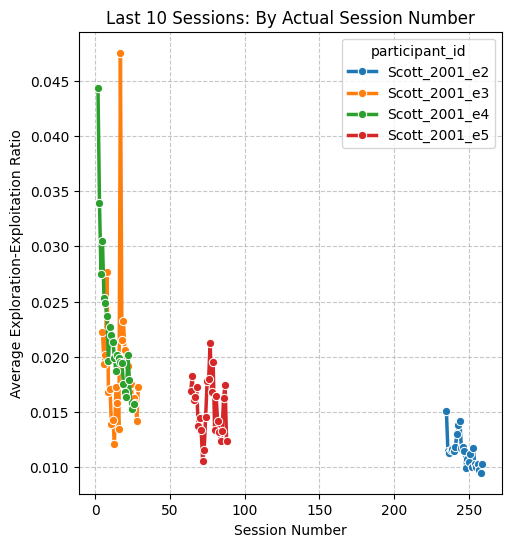

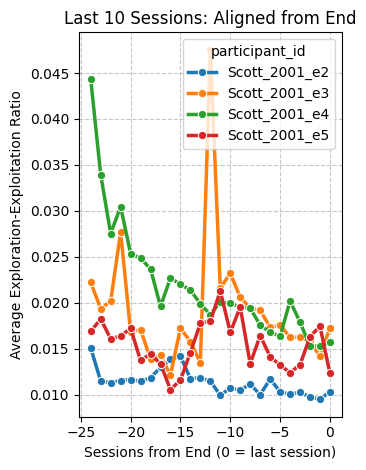

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random

save_path = "/plots/"

participant_ids = df_with_ratio_progress["participant_id"].unique().tolist()
# participant_ids = ["Scott_2001_e2", "Scott_2001_e3", "Scott_2001_e4", "Scott_2001_e5"]
print(participant_ids)
session_nos = df_with_ratio_progress["session_no"].unique().tolist()
trial_nos = df_with_ratio_progress["trial_no"].unique().tolist()
sessions_per_participant = df_with_ratio_progress.groupby('participant_id')['session_no'].nunique()
print("\nNumber of sessions per participant:")
print(sessions_per_participant)

last_sessions_data = []
for p_id in participant_ids:
    participant_data = df_with_ratio_progress[df_with_ratio_progress['participant_id'] == p_id]
    max_sessions = participant_data['session_no'].max()
    start_session = max(1, max_sessions - 24)  # Starting session for last 10 (or fewer)
    last_sessions = participant_data[participant_data['session_no'] >= start_session]
    last_sessions_data.append(last_sessions)
    
# Combine all participants' last sessions
last_sessions_df = pd.concat(last_sessions_data)
# print(last_sessions_df)

# Calculate average exploration_exploitation_ratio for each participant and session
session_avg = last_sessions_df.groupby(['participant_id', 'session_no'])['exploration_exploitation_ratio'].mean().reset_index()

# Create a new column showing how many sessions from the end (to align plots)
session_avg = session_avg.sort_values(['participant_id', 'session_no'])
session_counts = session_avg.groupby('participant_id').size()
for p_id in participant_ids:
    participant_sessions = session_avg[session_avg['participant_id'] == p_id]
    session_count = len(participant_sessions)
    session_avg.loc[session_avg['participant_id'] == p_id, 'sessions_from_end'] = \
        range(-session_count + 1, 1)

# Plot average exploration_exploitation_ratio for the last 10 sessions
plt.figure(figsize=(12, 6))

# Plot 1: By actual session number
plt.subplot(1, 2, 1)
sns.lineplot(data=session_avg, x='session_no', y='exploration_exploitation_ratio', 
             hue='participant_id', marker='o', linewidth=2.5)
plt.title('Last 10 Sessions: By Actual Session Number')
plt.xlabel('Session Number')
plt.ylabel('Average Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.subplot(1, 2, 2)
sns.lineplot(data=session_avg, x='sessions_from_end', y='exploration_exploitation_ratio', 
             hue='participant_id', marker='o', linewidth=2.5)
plt.title('Last 10 Sessions: Aligned from End')
plt.xlabel('Sessions from End (0 = last session)')
plt.ylabel('Average Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

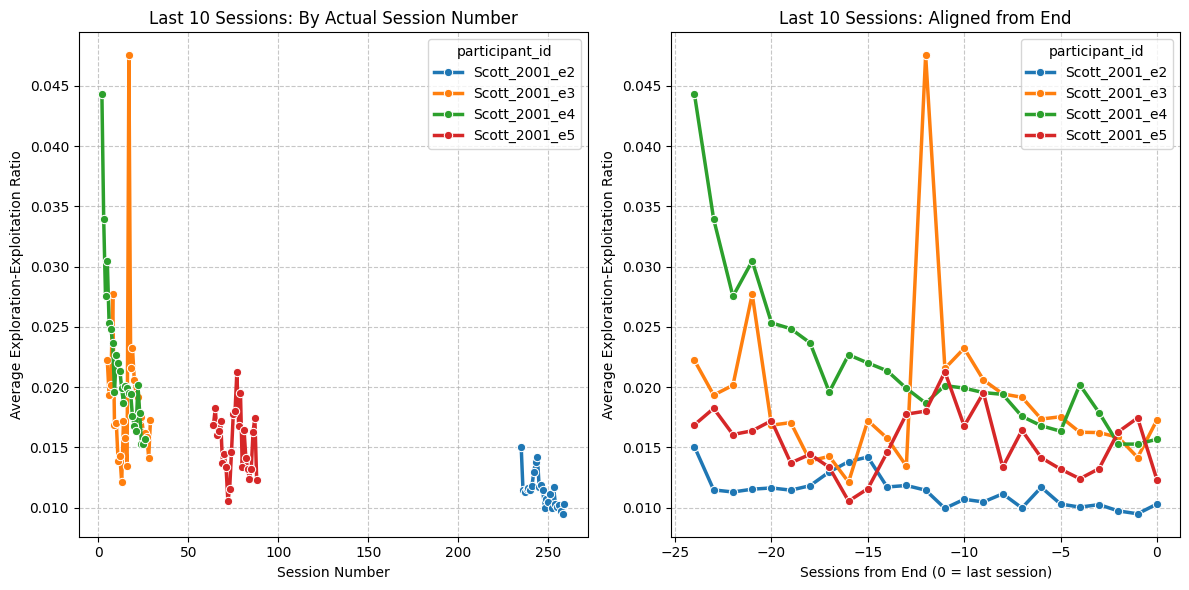

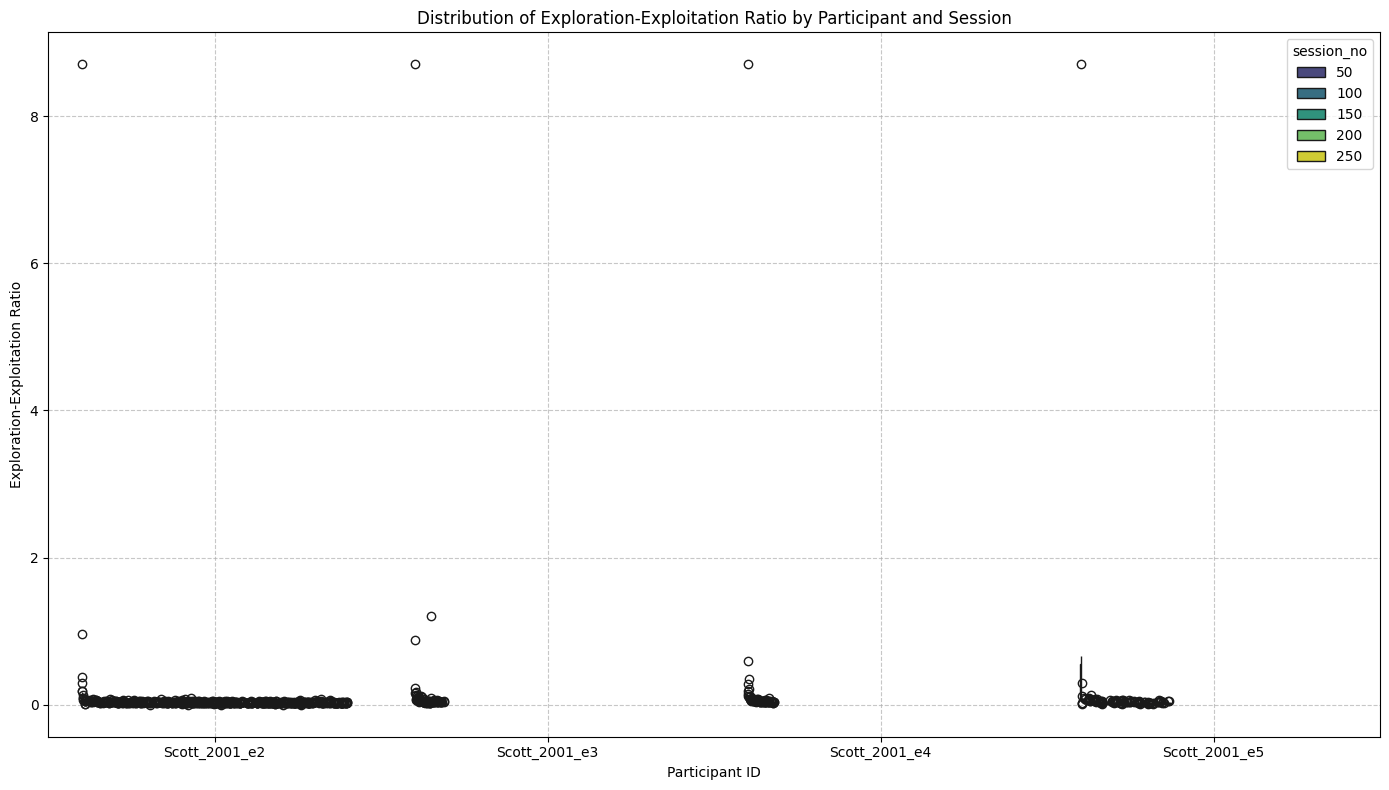


Summary Statistics by Participant and Trial (averaged across sessions):
  participant_id  trial_no      mean       std       min       max  count
0  Scott_2001_e2         1  0.046717  0.540106  0.001817  8.704692    259
1  Scott_2001_e2         2  0.017147  0.059044  0.003666  0.956004    259
2  Scott_2001_e2         3  0.014067  0.019216  0.001986  0.300990    259
3  Scott_2001_e2         4  0.014389  0.010005  0.001278  0.098940    259
4  Scott_2001_e2         5  0.013853  0.012309  0.002942  0.171993    259
5  Scott_2001_e2         6  0.012946  0.007083  0.001715  0.051271    259
6  Scott_2001_e2         7  0.014131  0.008921  0.002122  0.091399    259
7  Scott_2001_e2         8  0.014761  0.023157  0.002634  0.370504    259
8  Scott_2001_e2         9  0.014125  0.007565  0.003556  0.060940    259
9  Scott_2001_e2        10  0.014261  0.010329  0.001816  0.120574    259

Average exploration_exploitation_ratio for last 10 sessions:
  participant_id  exploration_exploitation_ratio
0 

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_11185/1286891097.py:73: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df_with_ratio_progress, x='trial_no', y='exploration_exploitation_ratio',


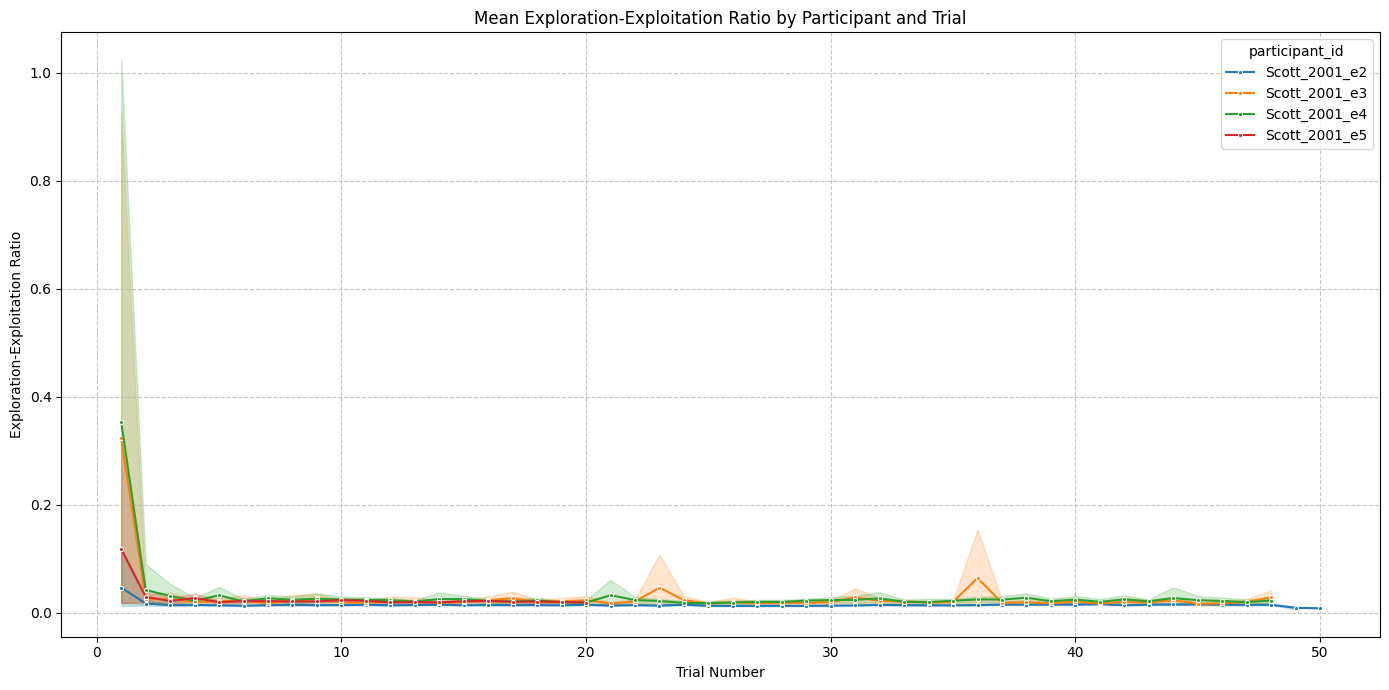

In [11]:
# Plot average exploration_exploitation_ratio for the last 10 sessions
plt.figure(figsize=(12, 6))

# Plot 1: By actual session number
plt.subplot(1, 2, 1)
sns.lineplot(data=session_avg, x='session_no', y='exploration_exploitation_ratio', 
             hue='participant_id', marker='o', linewidth=2.5)
plt.title('Last 10 Sessions: By Actual Session Number')
plt.xlabel('Session Number')
plt.ylabel('Average Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Aligned by sessions from end
plt.subplot(1, 2, 2)
sns.lineplot(data=session_avg, x='sessions_from_end', y='exploration_exploitation_ratio', 
             hue='participant_id', marker='o', linewidth=2.5)
plt.title('Last 10 Sessions: Aligned from End')
plt.xlabel('Sessions from End (0 = last session)')
plt.ylabel('Average Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
# plt.savefig('last_10_sessions_plot.png')

# Plot 2: Box plot to show distribution by participant and session
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_with_ratio_progress, x='participant_id', y='exploration_exploitation_ratio', 
            hue='session_no', palette='viridis')
plt.title('Distribution of Exploration-Exploitation Ratio by Participant and Session')
plt.xlabel('Participant ID')
plt.ylabel('Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('participant_session_boxplot.png')
plt.show()

# 2) Analyze participant and trial wise 'exploration_exploitation_ratio' statistics with plot

# Calculate summary statistics by participant and trial (across all sessions)
trial_stats = df_with_ratio_progress.groupby(['participant_id', 'trial_no'])['exploration_exploitation_ratio'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).reset_index()

print("\nSummary Statistics by Participant and Trial (averaged across sessions):")
print(trial_stats.head(10))  # Show first 10 rows for brevity

# Additional analysis: Calculate average exploration_exploitation_ratio across all trials
# for the last 10 sessions only
print("\nAverage exploration_exploitation_ratio for last 10 sessions:")
last_sessions_avg = last_sessions_df.groupby('participant_id')['exploration_exploitation_ratio'].mean().reset_index()
print(last_sessions_avg)

# Statistical test: ANOVA to test differences between participants in last 10 sessions
last_session_participants = [last_sessions_df[last_sessions_df['participant_id'] == p_id]['exploration_exploitation_ratio'] 
                           for p_id in participant_ids]
print("\nANOVA for Participant Effect (Last 10 Sessions):")
f_stat, p_val = stats.f_oneway(*last_session_participants)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

# Linear regression analysis to assess trial effect
from scipy import stats

print("\nAnalyzing trial effect on exploration-exploitation ratio:")
for p_id in participant_ids:
    participant_data = df_with_ratio_progress[df_with_ratio_progress['participant_id'] == p_id]
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        participant_data['trial_no'], participant_data['exploration_exploitation_ratio'])
    print(f"Participant {p_id}: Slope = {slope:.4f}, p-value = {p_value:.4f}, R² = {r_value**2:.4f}")

# Plot 3: Line plot of mean ratios by participant and trial
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_with_ratio_progress, x='trial_no', y='exploration_exploitation_ratio', 
             hue='participant_id', marker='.', ci=95)
plt.title('Mean Exploration-Exploitation Ratio by Participant and Trial')
plt.xlabel('Trial Number')
plt.ylabel('Exploration-Exploitation Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('participant_trial_plot.png')
plt.show()

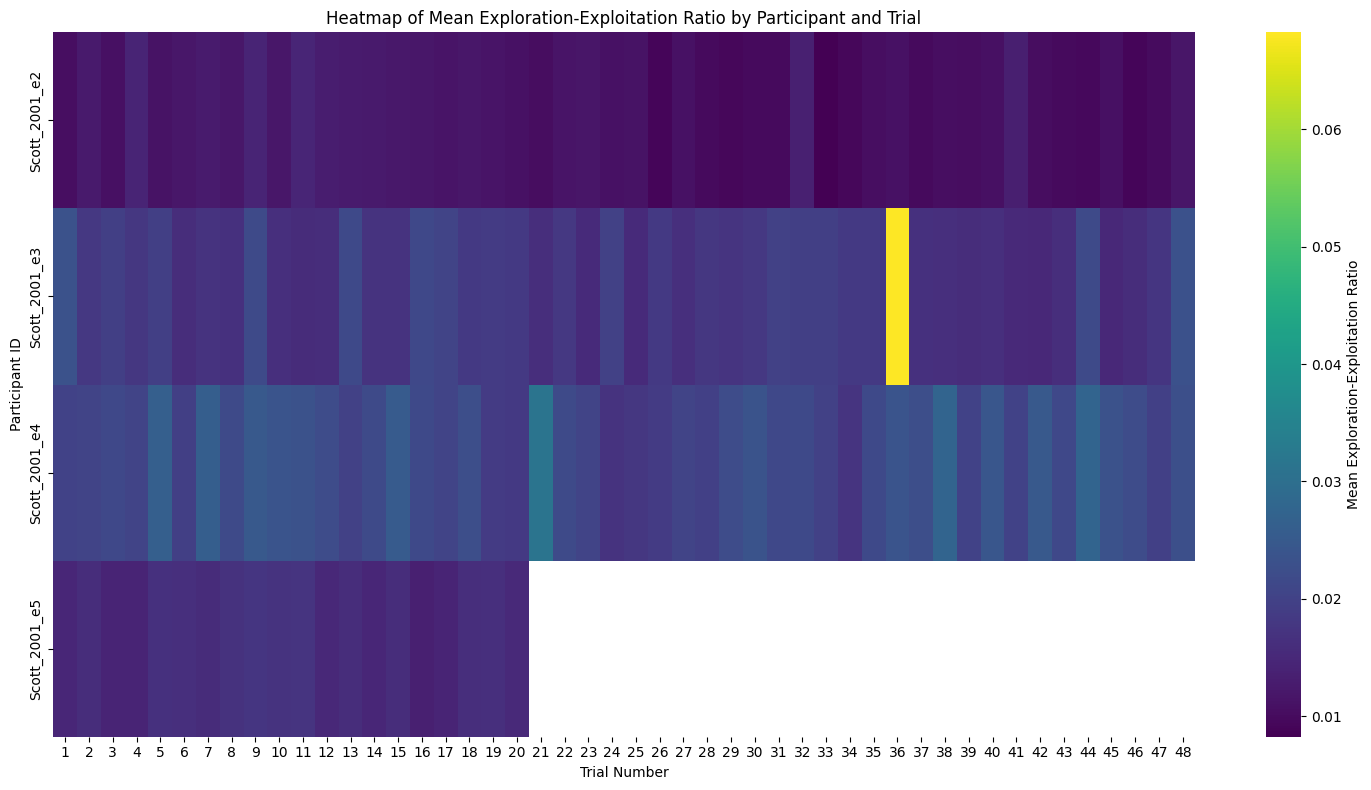

In [12]:
# Average across sessions for each participant and trial
heatmap_data = last_sessions_df.groupby(['participant_id', 'trial_no'])['exploration_exploitation_ratio'].mean().unstack()

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=False, fmt='.2f', cbar_kws={'label': 'Mean Exploration-Exploitation Ratio'})
plt.title('Heatmap of Mean Exploration-Exploitation Ratio by Participant and Trial')
plt.xlabel('Trial Number')
plt.ylabel('Participant ID')
plt.tight_layout()
# plt.savefig('participant_trial_heatmap.png')
plt.show()


# Advanced plot: Facet grid to show individual participant trends across trials and sessions
g = sns.FacetGrid(last_sessions_df, col='participant_id', row='session_no', 
                  height=4, aspect=1.5, sharex=True, sharey=True)
g.map_dataframe(sns.lineplot, x='trial_no', y='exploration_exploitation_ratio')
g.add_legend()
g.fig.suptitle('Exploration-Exploitation Ratio Trends by Participant, Session, and Trial', y=1.05)
g.set_axis_labels('Trial Number', 'Exploration-Exploitation Ratio')
g.tight_layout()
# plt.savefig('participant_session_trial_facet.png')
plt.show()